In [1]:
%pylab inline
import xarray
import pandas as pd
from geoutils.figures import Figures
from os.path import basename
import datetime as dt

Populating the interactive namespace from numpy and matplotlib


In [2]:
filename = '/rfs/proj/C3S/merra_aeronet_1999_2005_v2.nc'
filename = '/rfs/proj/C3S/merra_aeronet_2010_2015_v2.nc'
filename = '/rfs/proj/C3S/merra_aeronet_2010_2015_v3.nc'
filename = '/rfs/proj/C3S/merra_aeronet_2010_cabauw_v3.nc'
filename = '/rfs/proj/C3S/validation_merra_aeronet/merra_aeronet_2012_hourly.nc'
#year1 = basename(filename).split('_')[-3]
#year2 = basename(filename).split('_')[-2]
year = basename(filename).split('_')[-2]
correlation = xarray.open_mfdataset(filename)

/home/applis/anaconda/envs/py2v4.4/lib/python2.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in less_equal
/home/applis/anaconda/envs/py2v4.4/lib/python2.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in greater_equal
/home/applis/anaconda/envs/py2v4.4/lib/python2.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in less_equal
/home/applis/anaconda/envs/py2v4.4/lib/python2.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in greater_equal


{'N': 392664,
 'R2': 0.77998751753081308,
 'RMS': 0.10029590816119256,
 'bias': -0.013339617969141772,
 'eq': (0.73962801671960432, 0.037505381901641155),
 'gfrac': 0.8399675040237964,
 'reserr': 0.099404847901476814}

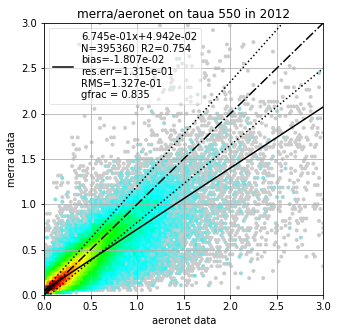

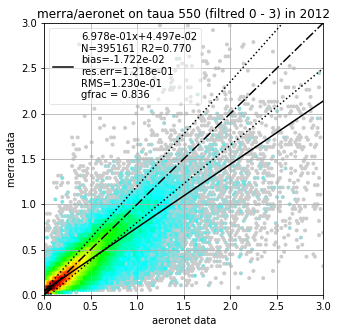

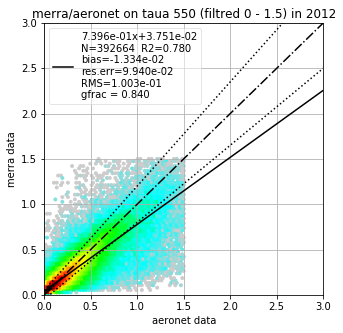

In [3]:
aeronet_taua550 = correlation.aeronet_taua550[:,:].values

#aeronet_taua500_to_550 = ((550./500.)**(-correlation.aeronet_angstrom500_870[:,:].values))*correlation.aeronet_taua500[:,:].values
#aeronet_taua440_to_550 = ((550./440.)** (-correlation.aeronet_angstrom440_675[:,:].values))*correlation.aeronet_taua440[:,:].values
merra_taua = correlation['merra_taua550'][:,:].values

#filtre_nan = ((~isnan(aeronet_taua550)) & (~isnan(merra_taua)))
#filtre_nan_500 = ((~isnan(aeronet_taua500_to_550)) & (~isnan(merra_taua)) & (aeronet_taua500_to_550>0) & (merra_taua>0))
#filtre_nan_500 &= (aeronet_taua500_to_550 < 10)
#filtre_nan_440 = ((~isnan(aeronet_taua440_to_550)) & (~isnan(merra_taua)) & (aeronet_taua440_to_550>0) & (merra_taua>0))
#filtre_nan_440 &= (aeronet_taua440_to_550 < 10)

fig = Figures(rows=1)
titre='merra/aeronet'+' on taua 550 in {}'.format(year)
fig.plot_scatter(fmt='density', X0=aeronet_taua550, Y0=merra_taua, title=titre, show=['R2','linregress','bias','relative_bias','N','eq','reserr','RMS', 'gfrac'], ylabel='merra data', xlabel='aeronet data', range=(0,3,0,3))
#fig.plot_scatter(fmt='density', Y0=aeronet_taua550, X0=merra_taua, title=titre, show=['R2','linregress','bias','relative_bias','N','eq','reserr','RMS','gfrac'], xlabel='merra data', ylabel='aeronet data', range=(0,3,0,3))

fig = Figures()
filtre = ((aeronet_taua550<=3) & (aeronet_taua550>=0) & (merra_taua<=3) & (merra_taua>=0))
titre='merra/aeronet'+' on taua 550 (filtred 0 - 3) in {}'.format(year)
fig.plot_scatter(fmt='density', Y0=merra_taua[filtre], X0=aeronet_taua550[filtre], title=titre, show=['R2','linregress','bias','relative_bias','N','eq','reserr','RMS','gfrac'], ylabel='merra data', xlabel='aeronet data', range=(0,3,0,3))

fig = Figures()
filtre = ((aeronet_taua550<=1.5) & (aeronet_taua550>=0) & (merra_taua<=1.5) & (merra_taua>=0))
titre='merra/aeronet'+' on taua 550 (filtred 0 - 1.5) in {}'.format(year)
fig.plot_scatter(fmt='density', Y0=merra_taua[filtre], X0=aeronet_taua550[filtre], title=titre, show=['R2','linregress','bias','relative_bias','N','eq','reserr','RMS','gfrac'], ylabel='merra data', xlabel='aeronet data', range=(0,3,0,3))

<xarray.DataArray 'aeronet_taua440' (date: 8760)>
dask.array<getitem, shape=(8760,), dtype=float64, chunksize=(8760,)>
Coordinates:
  * date     (date) datetime64[ns] 1998-01-01 1998-01-01T01:00:00 ...
    site     |S19 'Alta_Floresta'


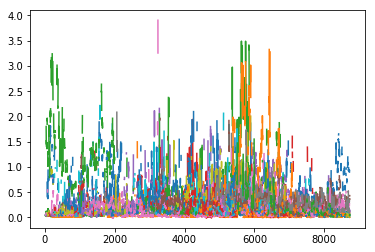

In [12]:
taua = correlation.aeronet_taua440.loc[:,:].values
filtre = ~isnan(taua)

plot(taua)
print correlation.aeronet_taua440.loc[:,'Alta_Floresta']



{'N': 7,
 'R2': 0.31636303718742687,
 'RMS': 0.012797940199115355,
 'bias': 0.011949609180964662,
 'eq': (0.63661648317819186, 0.023936683504197667),
 'gfrac': 1.0,
 'reserr': 0.0045819334087629296}

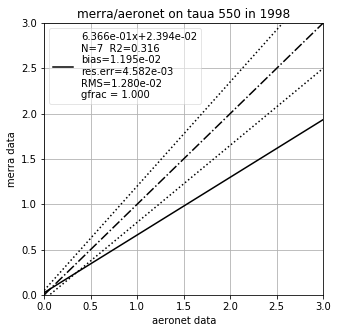

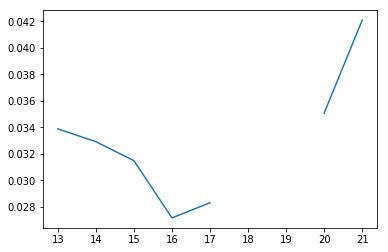

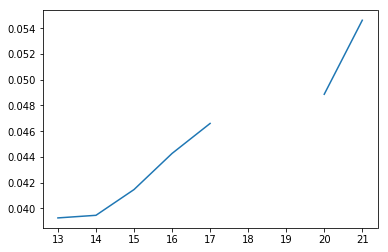

In [69]:
date_min = pd.to_datetime(np.min(correlation.date.values))
date_max = pd.to_datetime(np.max(correlation.date.values))

ndate = (date_max-date_min).days
date_min -= dt.timedelta(hours=date_min.hour)


filtre_date = ((correlation.date>=np.datetime64('1998-01-01')) & (correlation.date<=np.datetime64('1998-01-02')))
aeronet_taua550 = correlation.aeronet_taua550.loc[filtre_date,'GSFC'].values
merra_taua = correlation.merra_taua550.loc[filtre_date,'GSFC'].values
'''for site in correlation.site:
    values = correlation.aeronet_taua550.loc[filtre_date,site].values
    tot = np.nansum(values)
    
    if tot == 0:
        continue
    print site, tot
'''
figure()
plot(aeronet_taua550)
figure()
plot(merra_taua)
fig = Figures(rows=1)
titre = 'merra/aeronet'+' on taua 550 in {}'.format(year)
fig.plot_scatter(fmt='density', Y0=merra_taua, X0=aeronet_taua550, title=titre, show=['R2','linregress','bias','relative_bias','N','eq','reserr','RMS','gfrac'], ylabel='merra data', xlabel='aeronet data', range=(0,3,0,3))